# Dinámica de la Desigualdad Espacial

En esta clase estudiamos cómo medir la desigualdad económica entre regiones y, sobre todo, cómo incorporar el **espacio** en esas mediciones. La pregunta de fondo es:

Trabajaremos con datos de ingreso per cápita de los condados de Estados Unidos entre 1969 y 2017. Es un dataset particularmente útil porque combina dos dimensiones que rara vez vemos juntas:

- **Espacial:** más de 3000 condados con geometría conocida.
- **Temporal:** casi 50 años de observaciones para cada condado.

## Lo que veremos

1. Medidas clásicas de desigualdad (no espaciales): ratio 20:20, índice de Gini, índice de Theil.
2. La diferencia entre desigualdad **personal** y desigualdad **regional**.
3. Tres formas de meter el espacio en el análisis:
   - Autocorrelación espacial del ingreso (Moran's I).
   - Descomposición regional del índice de Theil (componentes *entre* y *dentro*).
   - Gini espacial: separar diferencias entre vecinos vs. no vecinos.

Adaptado de Rey, Arribas-Bel & Wolf (2020), *Geographic Data Science with Python*, Capítulo 9.

## 1. Preparación: librerías y datos

In [37]:
import seaborn
import pandas
import geopandas
import numpy
import esda
import matplotlib.pyplot as plt
from libpysal import weights
from pysal.explore import inequality
%config InlineBackend.figure_format = "retina"

In [38]:
# Cargamos el dataset de ingreso per cápita por condado
pci_df = geopandas.read_file(
    "datos/external/us_county_income/uscountypcincome.gpkg"
)
pci_df.shape

(3076, 77)

Tenemos 3076 condados (filas) y 77 columnas. Veamos cómo están organizadas las columnas:

In [39]:
pci_df.columns.tolist()

['STATEFP',
 'COUNTYFP',
 'COUNTYNS',
 'GEOID',
 'NAME',
 'NAMELSAD',
 'LSAD',
 'CLASSFP',
 'MTFCC',
 'CSAFP',
 'CBSAFP',
 'METDIVFP',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'GeoFIPS',
 'GeoName',
 'Region',
 'TableName',
 'LineCode',
 'Descriptio',
 'Unit',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 'index',
 'IndustryCl',
 'Descript_1',
 'geometry']

In [40]:

pci_df.loc[(pci_df["NAME"] == "Jackson") & (pci_df["STATEFP"] == "28"), "1969":"1979"]

,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979
1417,2957,3121,3327,3939,4203,4547,5461,5927,6315,6619,6967


## 2. Visualización inicial

Antes de calcular índices, miremos la distribución del ingreso. Hay dos visualizaciones complementarias:

- Un **histograma**: muestra la forma de la distribución de valores (la *feature*).
- Un **mapa coroplético**: muestra la distribución *geográfica*.

Las dos cuentan historias distintas. Necesitamos las dos.

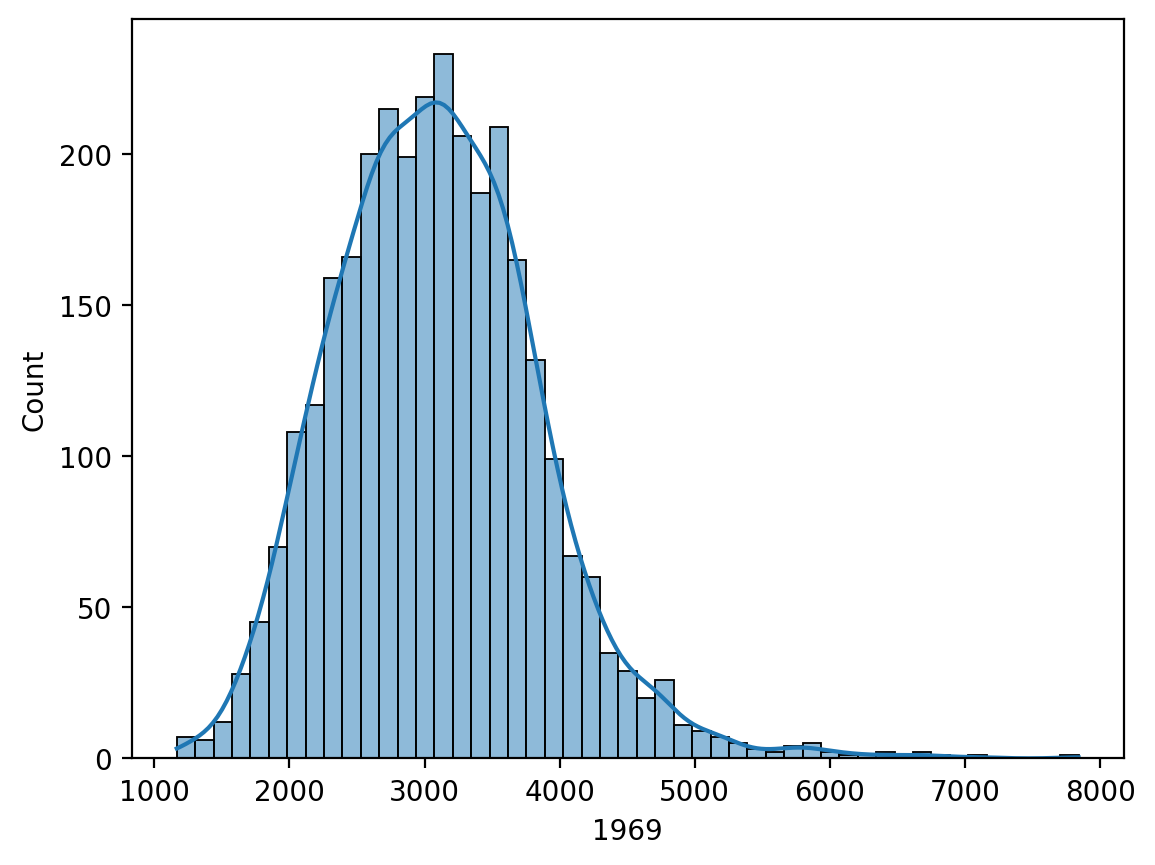

In [41]:
seaborn.histplot(x=pci_df["1969"], kde=True);

La distribución tiene una **cola larga a la derecha** (sesgo positivo). Esto es característico de los ingresos: hay relativamente pocos súper-ricos y están *muy* lejos de la media.

**Nota importante:** estamos viendo *ingresos per cápita por condado*, no ingresos individuales. La agregación por condado suaviza la distribución: dentro de cada condado conviven ricos y pobres, pero solo vemos el promedio. Esto significa que nuestras conclusiones serán sobre *condados*, no sobre *personas*. Confundir ambos niveles se llama **falacia ecológica**.

In [42]:
# Reproyectamos a una proyección equivalente para mapear EE.UU.
pci_df = pci_df.to_crs(epsg=5070)  # Albers Equal Area Norteamérica

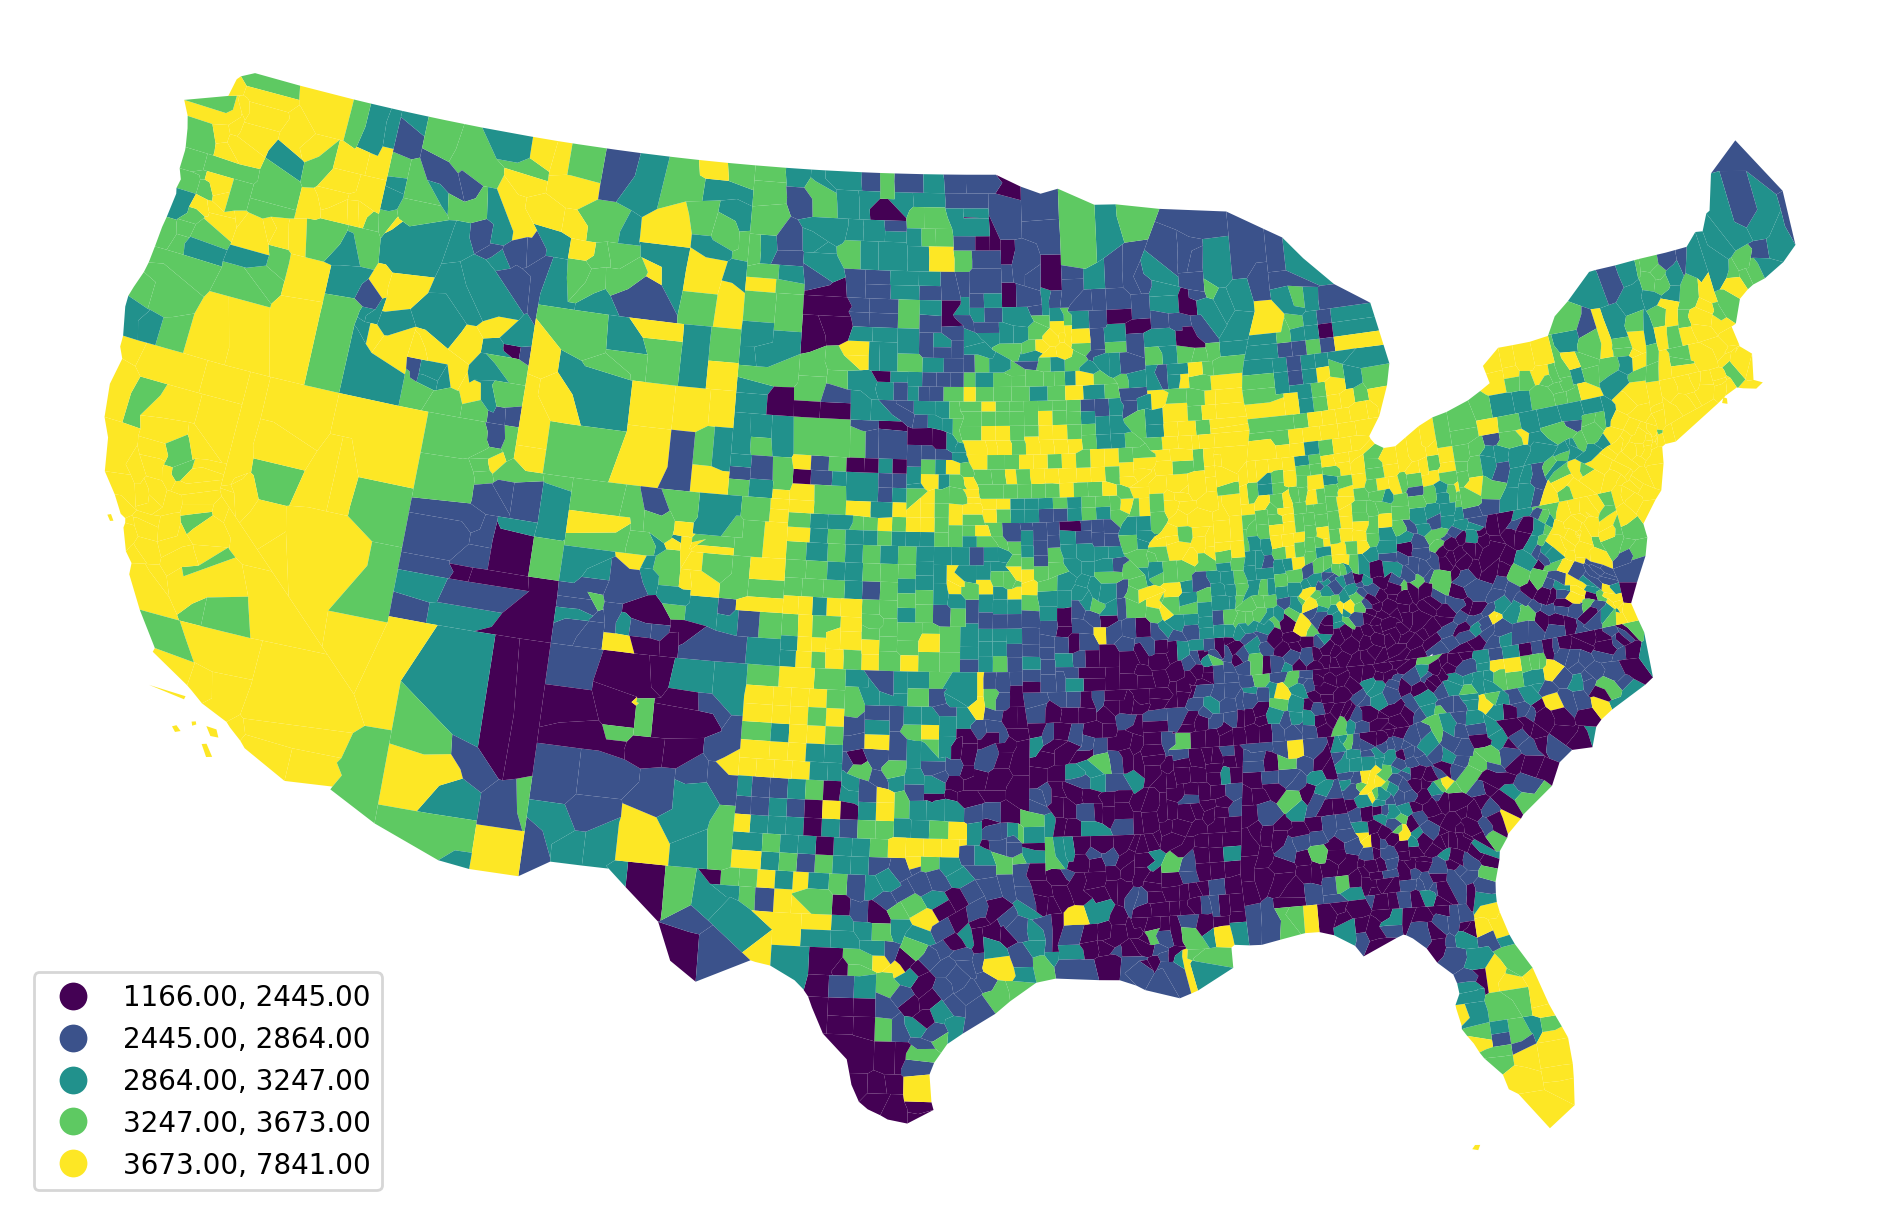

In [43]:
ax = pci_df.plot(
    column="1969",
    scheme="Quantiles",
    legend=True,
    edgecolor="none",
    legend_kwds={"loc": "lower left"},
    figsize=(12, 8),
)
ax.set_axis_off()
plt.show()

El mapa muestra patrones geográficos claros: el sur aparece consistentemente más pobre, las costas más ricas. El histograma no nos decía nada de esto.

## 3. Medidas globales de desigualdad

Ahora calcularemos índices que resumen la desigualdad en un solo número. "Globales" significa que describen la distribución completa, sin importar dónde está cada observación.

### 3.1 Ratio 20:20

Es la medida más simple: el ingreso del percentil 80 dividido por el del percentil 20.

$$ \text{Ratio 20:20} = \frac{P_{80}}{P_{20}} $$

Si vale 1, el rico y el pobre ganan lo mismo. Si vale 5, el rico gana 5 veces lo que el pobre. Su gracia es que ignora los extremos (super ricos y super pobres), así que es robusta a outliers.

In [44]:
top20, bottom20 = pci_df["1969"].quantile([0.8, 0.2])
ratio_1969 = top20 / bottom20
print(f"En 1969 el percentil 80 ganaba {ratio_1969:.2f} veces lo del percentil 20")

En 1969 el percentil 80 ganaba 1.50 veces lo del percentil 20


Para ver cómo evoluciona en el tiempo, definimos una función y la aplicamos a cada año:

In [45]:
def ratio_20_20(valores):
    p80, p20 = valores.quantile([0.8, 0.2])
    return p80 / p20

# Lista de años como strings 
anios = numpy.arange(1969, 2018).astype(str)

# Aplicamos la función a cada columna de año
ratio_2020 = pci_df[anios].apply(ratio_20_20, axis=0)

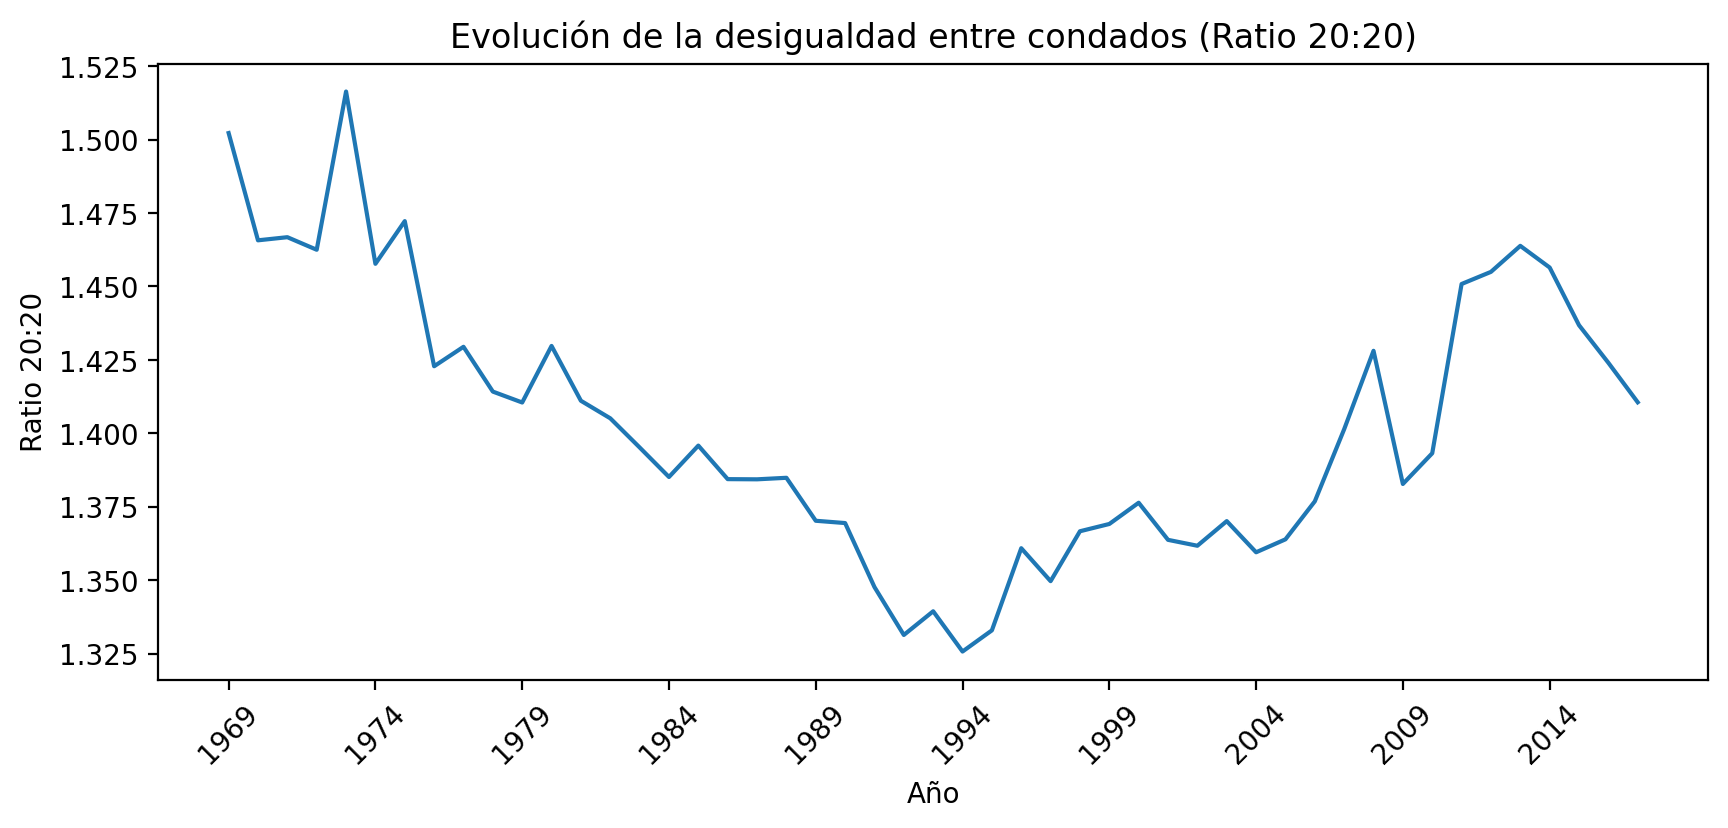

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(anios, ratio_2020)
ax.set_xticks(anios[::5])
ax.set_xlabel("Año")
ax.set_ylabel("Ratio 20:20")
ax.set_title("Evolución de la desigualdad entre condados (Ratio 20:20)")
plt.xticks(rotation=45)
plt.show()

El patrón tiene forma de U: la desigualdad cae hasta mediados de los 90, sube hasta 2013, y luego empieza a bajar de nuevo.

### 3.2 Índice de Gini

El Gini es probablemente el índice de desigualdad más conocido. Su construcción se basa en la **curva de Lorenz**, que grafica:

- En el eje X: el porcentaje acumulado de la población (ordenada de menor a mayor ingreso).
- En el eje Y: el porcentaje acumulado del ingreso total que poseen.

Si la sociedad fuera perfectamente igualitaria, el 50% más pobre tendría exactamente el 50% del ingreso, y el gráfico sería la diagonal. Cuanto más se aleja la curva real de la diagonal, más desigualdad hay.

**El Gini es exactamente eso: el área entre la curva de Lorenz y la línea de igualdad, normalizada.** Va de 0 (igualdad perfecta) a 1 (un solo individuo tiene todo).

In [47]:
# Curva de Lorenz para 1969 

# Ordenamos los ingresos de 1969 de menor a mayor
lorenz_1969 = (
    pci_df[["1969"]]
    .rename(columns={"1969": "Ingreso"})
    .sort_values("Ingreso")
    .reset_index(drop=True)
)
lorenz_1969.head()


,Ingreso
0,1166
1,1242
2,1244
3,1253
4,1293


In [48]:
#Calculamos el ingreso acumulado, 
#la proporción de ingreso acumulado 
#y la proporción de población acumulada 
#(asumiendo que cada condado tiene la misma población)

lorenz_1969["Ingreso_acumulado"] = lorenz_1969["Ingreso"].cumsum()
lorenz_1969["Prop_ingreso"] = (
    lorenz_1969["Ingreso_acumulado"] / lorenz_1969["Ingreso"].sum()
)
lorenz_1969["Prop_poblacion"] = (lorenz_1969.index + 1) / len(lorenz_1969)

lorenz_1969.head()

,Ingreso,Ingreso_acumulado,Prop_ingreso,Prop_poblacion
0,1166,1166,0.000122,0.000325
1,1242,2408,0.000253,0.000650
2,1244,3652,0.000384,0.000975
3,1253,4905,0.000515,0.001300
4,1293,6198,0.000651,0.001625


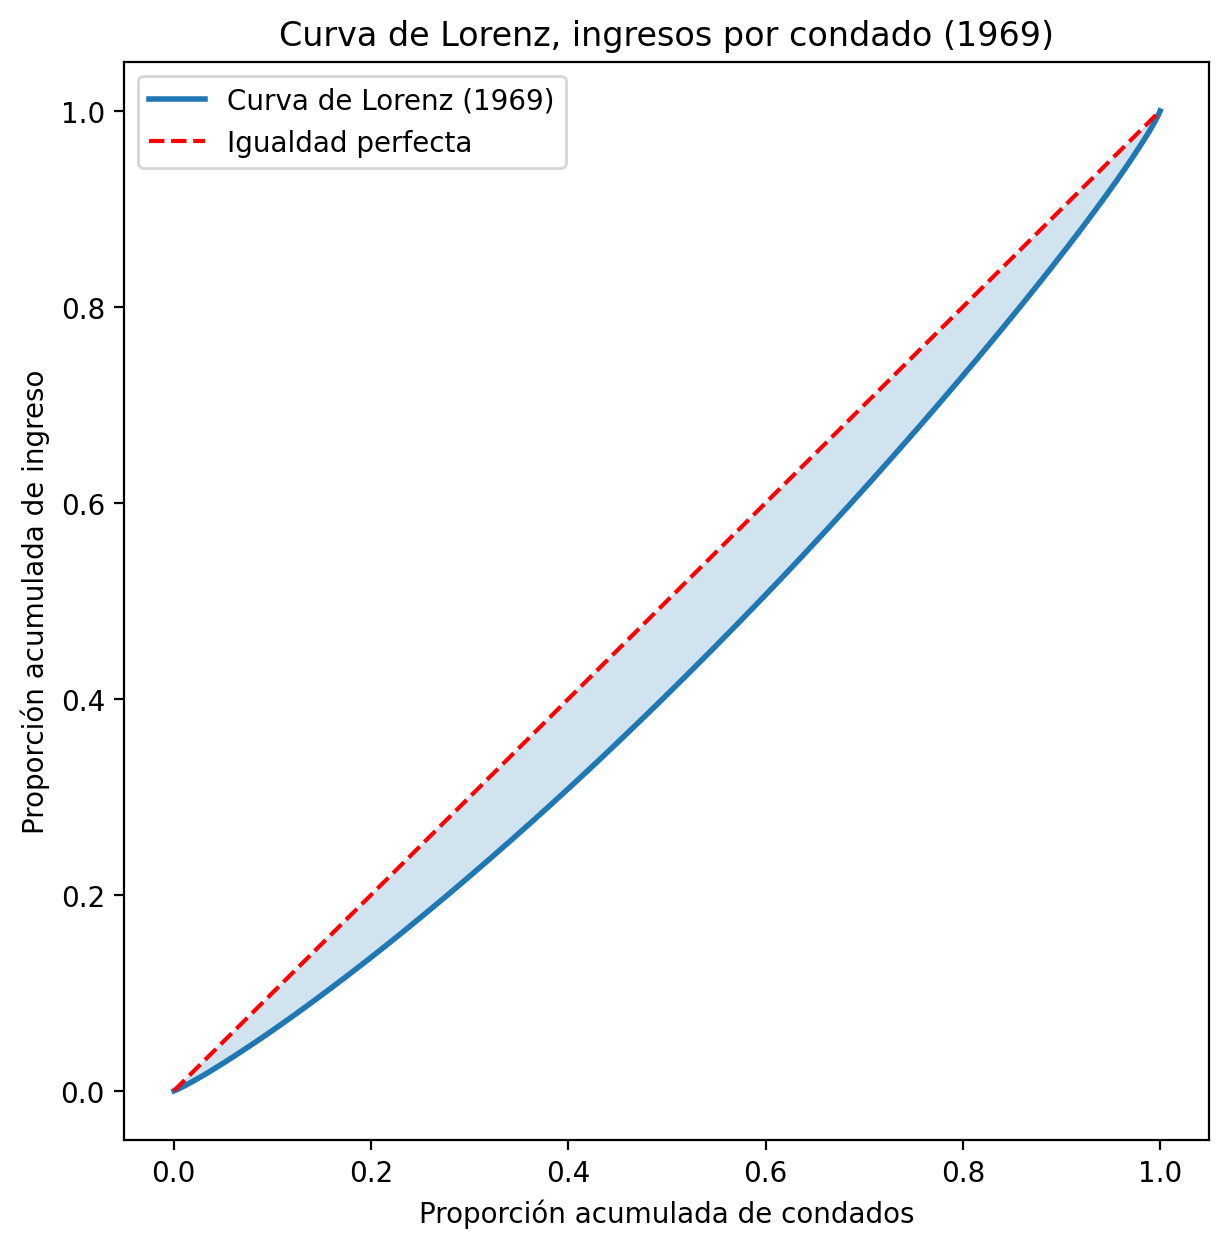

In [49]:

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(lorenz_1969["Prop_poblacion"], lorenz_1969["Prop_ingreso"],
        label="Curva de Lorenz (1969)", linewidth=2)
ax.plot([0, 1], [0, 1], color="red", linestyle="--",
        label="Igualdad perfecta")
ax.fill_between(lorenz_1969["Prop_poblacion"],
                lorenz_1969["Prop_poblacion"],
                lorenz_1969["Prop_ingreso"], alpha=0.2)
ax.set_xlabel("Proporción acumulada de condados")
ax.set_ylabel("Proporción acumulada de ingreso")
ax.set_title("Curva de Lorenz, ingresos por condado (1969)")
ax.legend()
plt.show()

El área sombreada entre las dos curvas es lo que captura el Gini.

Para calcular el Gini directamente, usamos la clase `Gini` de pysal:

### Forma equivalente: diferencias entre pares

La misma idea del *área entre Lorenz y la diagonal* se puede escribir como una suma de diferencias absolutas entre todos los pares de observaciones:

$$G \;=\; \frac{\sum_i\sum_j |y_i - y_j|}{2\,n^{2}\,\bar y}$$

- **Numerador:** suma todas las diferencias absolutas entre pares de condados. Si los ingresos son muy distintos entre sí, la suma es grande.
- **Denominador $2 n^2 \bar y$:** factor de normalización que garantiza $G \in [0, 1]$.
  - $n^2$ = número de pares ordenados $(i, j)$.
  - $\bar y$ hace que el índice sea invariante a la escala (\$1000 vs \$2000 dan el mismo Gini).
  - El $2$ corrige el doble conteo de pares ordenados.

Esta forma es la que se descompone en la **Sección 5.3** para separar diferencias entre vecinos y entre no-vecinos.


In [50]:
g69 = inequality.gini.Gini(pci_df["1969"].values)
print(f"Gini 1969: {g69.g:.4f}")

Gini 1969: 0.1356


Un valor de 0.135 es bajo. Atención: este es el Gini *entre condados*, no *entre personas*. El Gini de ingresos personales en EE.UU. está cerca de 0.4. 

Calculemos el Gini para todos los años:

In [51]:
def gini_de_columna(columna):
    return inequality.gini.Gini(columna.values).g

desigualdades = pci_df[anios].apply(gini_de_columna, axis=0).to_frame("Gini")
desigualdades.head()

,Gini
1969,0.135562
1970,0.130076
1971,0.128540
1972,0.129126
1973,0.142166


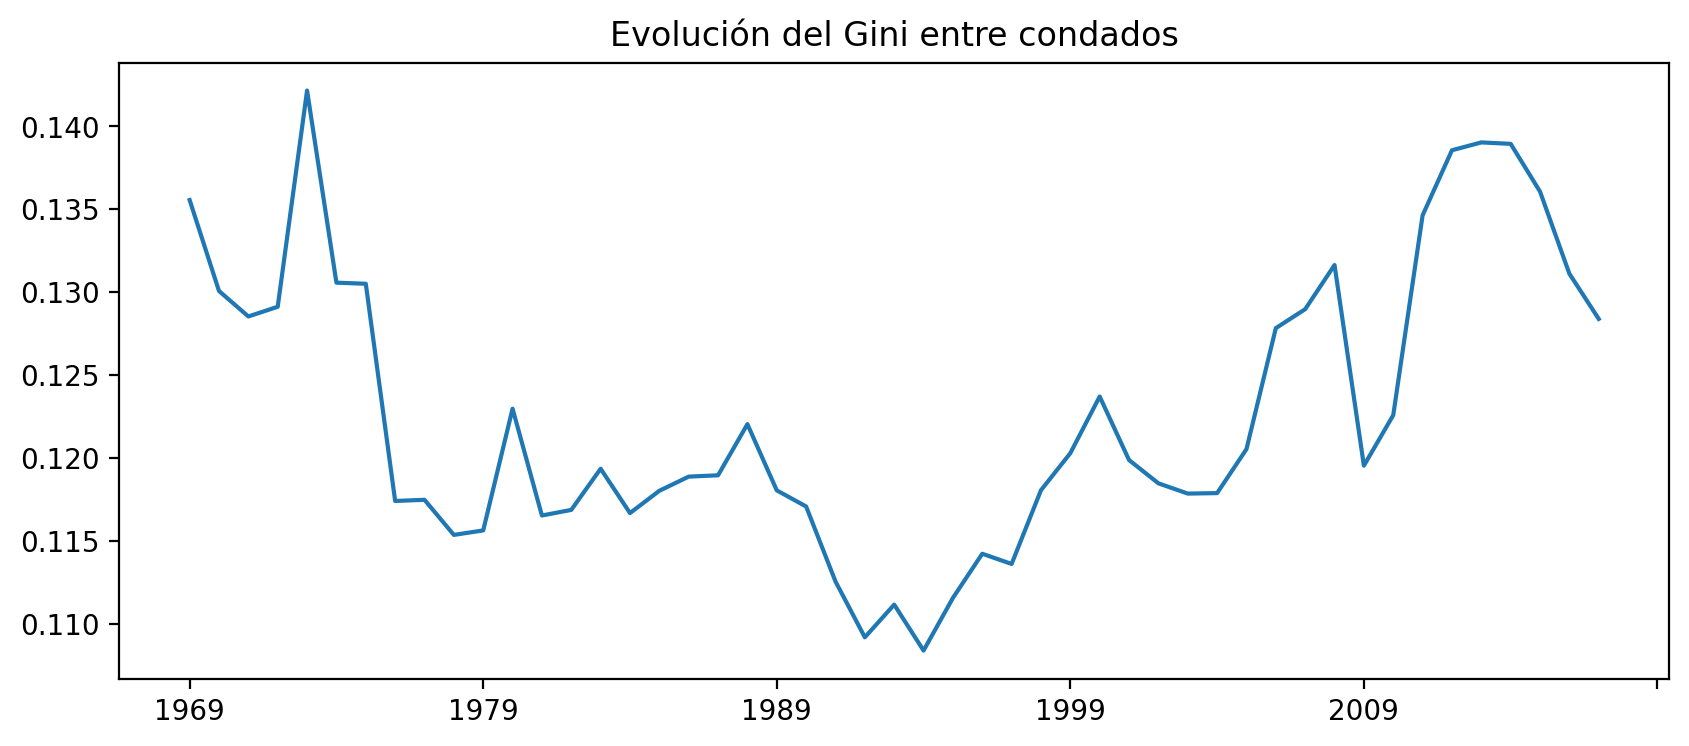

In [52]:
desigualdades["Gini"].plot(figsize=(10, 4), title="Evolución del Gini entre condados");

El patrón es similar al del ratio 20:20, lo que es consistente: ambos miden lo mismo desde ángulos distintos.

### 3.3 Índice de Theil

El tercer índice clásico es el de Theil. Conceptualmente está relacionado con la entropía: mide qué tan "uniformemente" se reparte el ingreso. Es 0 cuando todos tienen lo mismo y crece a medida que aparece más concentración.

$$
T = \frac{1}{m}\sum_{i=1}^{m} \frac{y_i}{\bar y}\,\ln\!\left(\frac{y_i}{\bar y}\right)
$$

donde $y_i$ es el ingreso del área $i$, $\bar y$ es el promedio de los ingresos, y $m$ es el número de áreas.

**Cómo leerla.** Cada sumando compara un área con el promedio:

- $y_i / \bar y$ es **cuántas veces el promedio** gana esa área. Vale 1 si $y_i$ es igual a $\bar y$.
- $\ln(y_i/\bar y)$ es positivo si está por arriba de la media, negativo si está por debajo, y cero si está justo en la media.
- El producto $\frac{y_i}{\bar y}\ln(\frac{y_i}{\bar y})$ pesa más a los que están **muy por arriba** del promedio que a los que están muy por abajo (porque arriba el factor $y_i/\bar y$ amplifica, abajo lo amortigua). Por eso el Theil es más sensible a los ricos que el Gini.

**Casos límite.**

- Si todos ganan lo mismo, $y_i = \bar y$ para todos $\Rightarrow \ln(1) = 0 \Rightarrow T = 0$.
- A medida que la distribución se concentra, $T$ crece. No tiene cota superior fija (al contrario del Gini, que vive en $[0, 1]$).

**Por qué nos interesa.** Es el único de los tres índices clásicos que se descompone limpiamente:

$$
T = T_{\text{entre regiones}} + T_{\text{dentro de regiones}}
$$

Esto nos permite responder *¿cuánta de la desigualdad viene de diferencias entre regiones, y cuánta de diferencias dentro de cada región?* — pregunta clave en la sección 5.2.



Su gran ventaja, que aprovecharemos más adelante, es que se puede separar en componentes entre regiones y dentro de regiones. El Gini no permite esto de manera tan limpia.

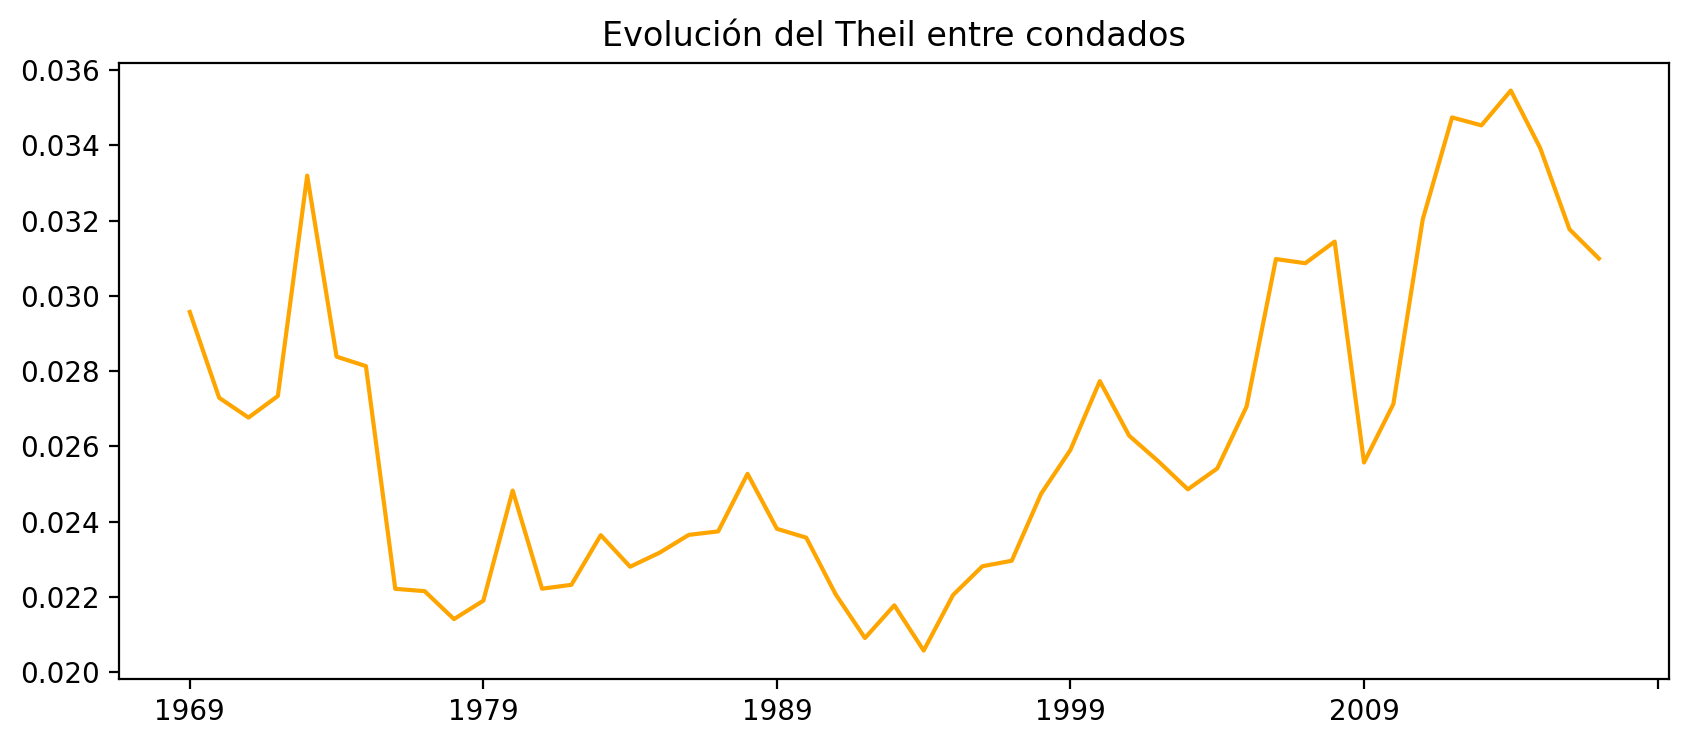

In [53]:
def theil_de_columna(columna):
    return inequality.theil.Theil(columna.values).T

desigualdades["Theil"] = pci_df[anios].apply(theil_de_columna, axis=0)

desigualdades["Theil"].plot(
    figsize=(10, 4), color="orange", title="Evolución del Theil entre condados"
);

### ¿Para qué tener tres índices si dan la misma forma?

A primera vista parecen redundantes. Pero no lo son del todo:

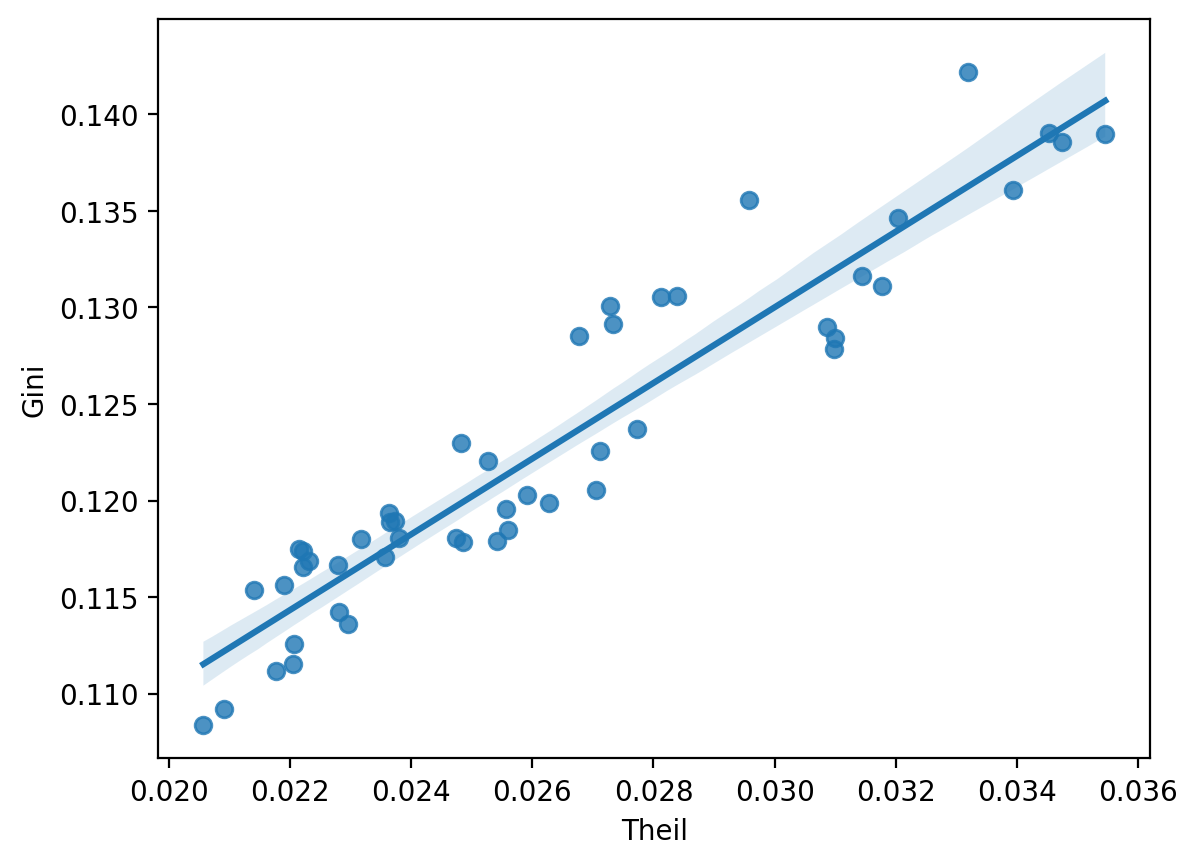

In [54]:
seaborn.regplot(x="Theil", y="Gini", data=desigualdades);

Están correlacionados pero no son perfectamente equivalentes. Cada uno tiene propiedades distintas:

- **Ratio 20:20** es robusto a outliers pero ignora todo lo que pasa en los extremos.
- **Gini** es sensible a cambios cerca de la mediana y permite descomposición espacial (como veremos).
- **Theil** se descompone naturalmente en partes "entre grupos" y "dentro de grupos".

En la práctica suele ser bueno reportar al menos dos para asegurarse de que las conclusiones no dependen del índice elegido.

## 4. Desigualdad personal vs. desigualdad regional

Hasta acá medimos desigualdad **entre condados**. Pero hay una distinción importante que se confunde con frecuencia.

Imaginemos un país hipotético con dos regiones:

- **Región A:** todos ganan exactamente $1000.
- **Región B:** la mitad gana $500, la otra mitad gana $1500. El promedio también es $1000.

**Desigualdad regional:** cero. Las dos regiones tienen el mismo ingreso promedio.

**Desigualdad personal:** alta. Dentro de B hay diferencias de 3 a 1.

Cuando trabajamos con datos agregados (como el ingreso *promedio* por condado), estamos asumiendo implícitamente que **dentro de cada condado todos ganan el promedio**. Es un supuesto fuerte, pero permite aislar la pregunta: *¿cuánta desigualdad existe entre lugares, independiente de la que hay dentro de cada lugar?*

Esto es lo que en el capítulo se llama "shift one level up the spatial hierarchy": subir de la persona al lugar.

Para responder preguntas sobre desigualdad personal necesitaríamos microdatos (encuestas tipo CASEN, ACS individual, etc.), no datos agregados como los que tenemos.

## 5. Desigualdad espacial

Acá llegamos a lo que distingue al análisis espacial del análisis económico tradicional. Los índices anteriores (Gini, Theil, ratio) **ignoran completamente la geografía**: si tomáramos los condados y los ordenáramos al azar en el mapa, los índices serían idénticos. Pero la geografía importa.

Veremos tres formas de incorporarla:

1. **Autocorrelación espacial:** ¿los condados ricos están cerca de otros condados ricos?
2. **Descomposición regional:** ¿cuánta de la desigualdad total viene de diferencias entre regiones (ej. Sur vs. Noreste) y cuánta de diferencias dentro de cada región?
3. **Gini espacial:** ¿las diferencias de ingreso son entre vecinos o entre lugares lejanos?

### 5.1 Autocorrelación espacial: Moran's I del ingreso

Calculamos el Moran's I del ingreso para cada año. Si es positivo y significativo, hay clusters espaciales: condados ricos junto a condados ricos, condados pobres junto a condados pobres.

### Fórmula

$$I \;=\; \frac{n}{\sum_i\sum_j w_{ij}}\,\frac{\sum_i\sum_j w_{ij}\,z_i\,z_j}{\sum_i z_i^{\,2}}$$

con $z_i = y_i - \bar y$. Vista en clase 04 — la repetimos porque ahora la aplicamos al **ingreso** y la observamos a lo largo del tiempo.


In [55]:
pci_df.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,2012,2013,2014,2015,2016,2017,index,IndustryCl,Descript_1,geometry
0,55,111,01581115,55111,Sauk,Sauk County,06,H1,G4020,357,...,39988,40655,42668,44255,44540,45847,NaN,None,None,"POLYGON ((466894.973 2298945.364, 457338.659 2..."
1,55,093,01581107,55093,Pierce,Pierce County,06,H1,G4020,378,...,39121,39367,41626,43539,43488,44636,NaN,None,None,"POLYGON ((261434.711 2415618.949, 258371.837 2..."
2,55,063,01581091,55063,La Crosse,La Crosse County,06,H1,G4020,None,...,41759,41230,43637,45067,45985,47134,NaN,None,None,"POLYGON ((372119.170 2333611.502, 365540.933 2..."
3,55,033,01581076,55033,Dunn,Dunn County,06,H1,G4020,232,...,35909,35940,36752,36835,37151,38345,NaN,None,None,"POLYGON ((304478.384 2445770.347, 301627.047 2..."
4,55,053,01581086,55053,Jackson,Jackson County,06,H1,G4020,None,...,39319,38620,40260,41189,41181,43185,NaN,None,None,"POLYGON ((384244.661 2381451.300, 382791.797 2..."


In [56]:
# Matriz de pesos por contigüidad tipo Queen
wq = weights.Queen.from_dataframe(pci_df)

/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_39625/497316946.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.Queen.from_dataframe(pci_df)


In [57]:
def moran_de_columna(y, w=wq):
    mo = esda.Moran(y, w=w)
    return pandas.Series({"I": mo.I, "p_valor": mo.p_sim})

moran_stats = pci_df[anios].apply(moran_de_columna, axis=0).T
moran_stats.head()

,I,p_valor
1969,0.649090,0.001
1970,0.647438,0.001
1971,0.626546,0.001
1972,0.606760,0.001
1973,0.640226,0.001


In [58]:
desigualdades.head()

,Gini,Theil
1969,0.135562,0.029572
1970,0.130076,0.027290
1971,0.128540,0.026764
1972,0.129126,0.027336
1973,0.142166,0.033196


In [59]:
# Agregamos los resultados a nuestra tabla principal
desigualdades=desigualdades.join(moran_stats)
desigualdades.head()

,Gini,Theil,I,p_valor
1969,0.135562,0.029572,0.649090,0.001
1970,0.130076,0.027290,0.647438,0.001
1971,0.128540,0.026764,0.626546,0.001
1972,0.129126,0.027336,0.606760,0.001
1973,0.142166,0.033196,0.640226,0.001


desigualdades[["I", "p_valor"]].plot(subplots=True, figsize=(10, 6))
plt.show()

Hay dos cosas notables:

1. **Moran's I baja consistentemente en el tiempo.** Mientras los Gini/Theil tienen forma de U, Moran sigue cayendo. Esto significa que la **estructura geográfica** de la desigualdad se está debilitando: hay desigualdad, pero está cada vez menos concentrada espacialmente.
2. **El p-valor siempre es 0.001** (significativo). Aunque la autocorrelación cae, nunca deja de ser estadísticamente significativa.

**Lección importante:** la desigualdad agregada (Gini, Theil) y la estructura espacial de la desigualdad (Moran) son cosas distintas. Pueden moverse en direcciones distintas. El análisis espacial agrega información que los índices clásicos no capturan.

### 5.2 Descomposición regional del Theil

Una crítica habitual a los índices globales es que esconden el origen de la desigualdad. ¿Es porque hay diferencias *entre regiones* (el Sur vs. el Noreste)? ¿O porque dentro de cada región conviven condados muy distintos?

El Theil permite separar estos dos componentes:

$$ T = T_{\text{entre}} + T_{\text{dentro}} $$

- $T_{\text{entre}}$: cuánta desigualdad existe si reemplazamos cada condado por el promedio de su región. Mide diferencias entre regiones.
- $T_{\text{dentro}}$: cuánta desigualdad queda dentro de cada región, después de descontar las diferencias entre regiones.

Los datos vienen con una clasificación en 8 regiones censales:

### Fórmulas de descomposición

$$T \;=\; T_{\text{entre}} \;+\; T_{\text{dentro}}$$

donde el componente *dentro* es el promedio ponderado de los Theil regionales:

$$T_{\text{dentro}} \;=\; \sum_{g}\, s_g\, T_g \qquad \text{con}\qquad s_g \;=\; \frac{\sum_{i\in g} y_i}{\sum_i y_i}$$

- $T_g$ = Theil calculado **dentro** de la región $g$ (usando el promedio de esa región).
- $s_g$ = participación de la región $g$ en el ingreso total nacional.

Ver el ejemplo paso a paso en `presentaciones/clase06_theil_ejemplo.pdf`.


In [60]:
nombres_regiones = {
    1: "New England",
    2: "Mideast",
    3: "Great Lakes",
    4: "Plains",
    5: "Southeast",
    6: "Southwest",
    7: "Rocky Mountain",
    8: "Far West",
}

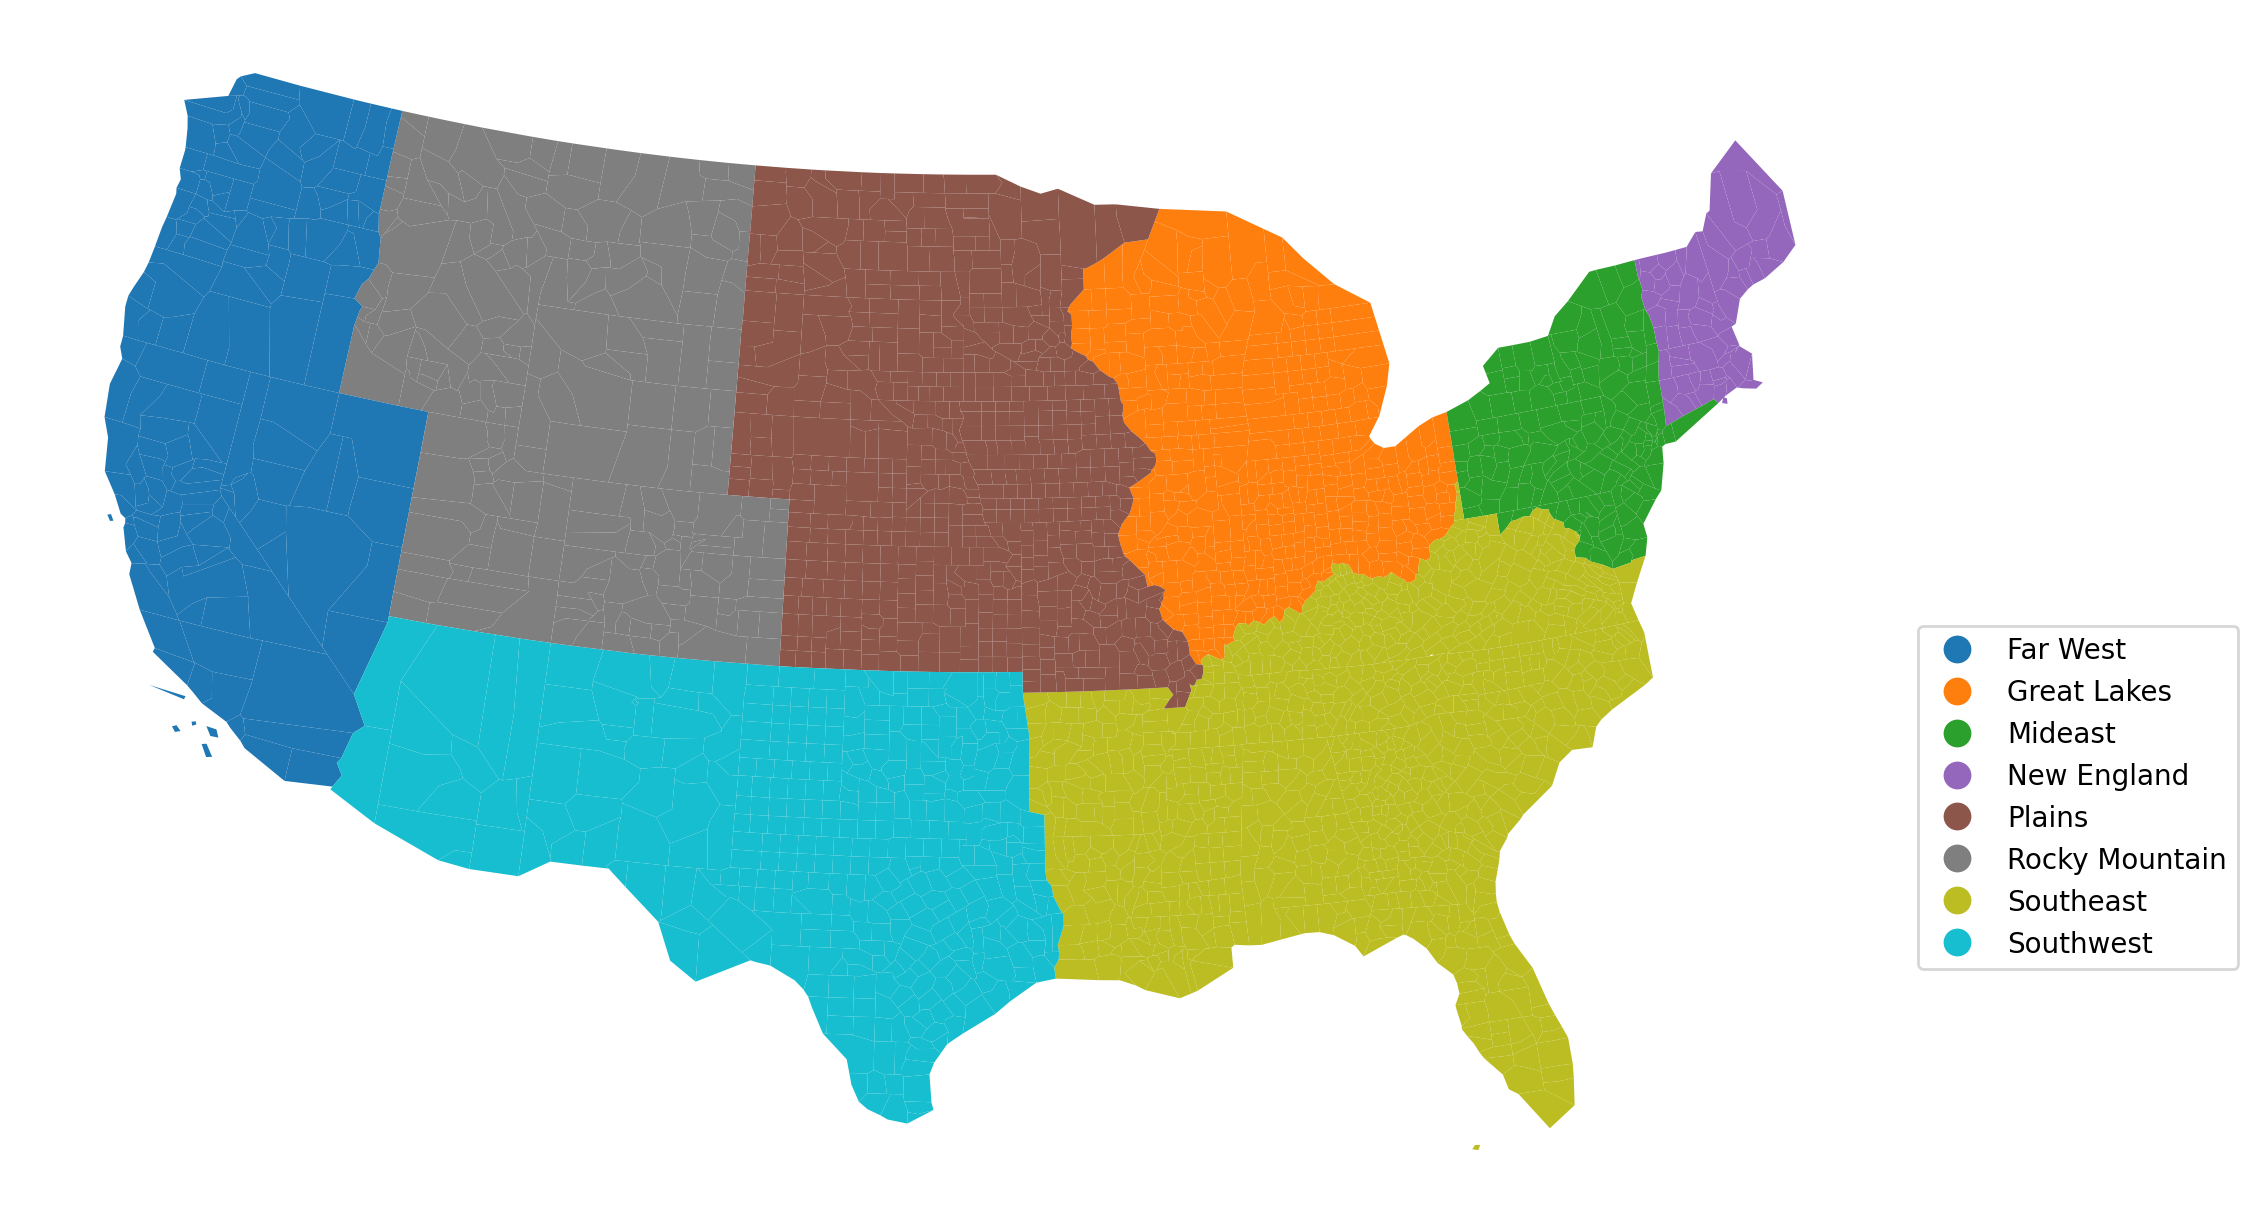

In [61]:
ax = pci_df.assign(
    Region_Name=pci_df.Region.map(nombres_regiones)
).plot(
    "Region_Name",
    linewidth=0,
    legend=True,
    categorical=True,
    legend_kwds=dict(bbox_to_anchor=(1.2, 0.5)),
    figsize=(12, 8),
)
ax.set_axis_off();

Veamos cómo evoluciona el ingreso promedio en cada región:

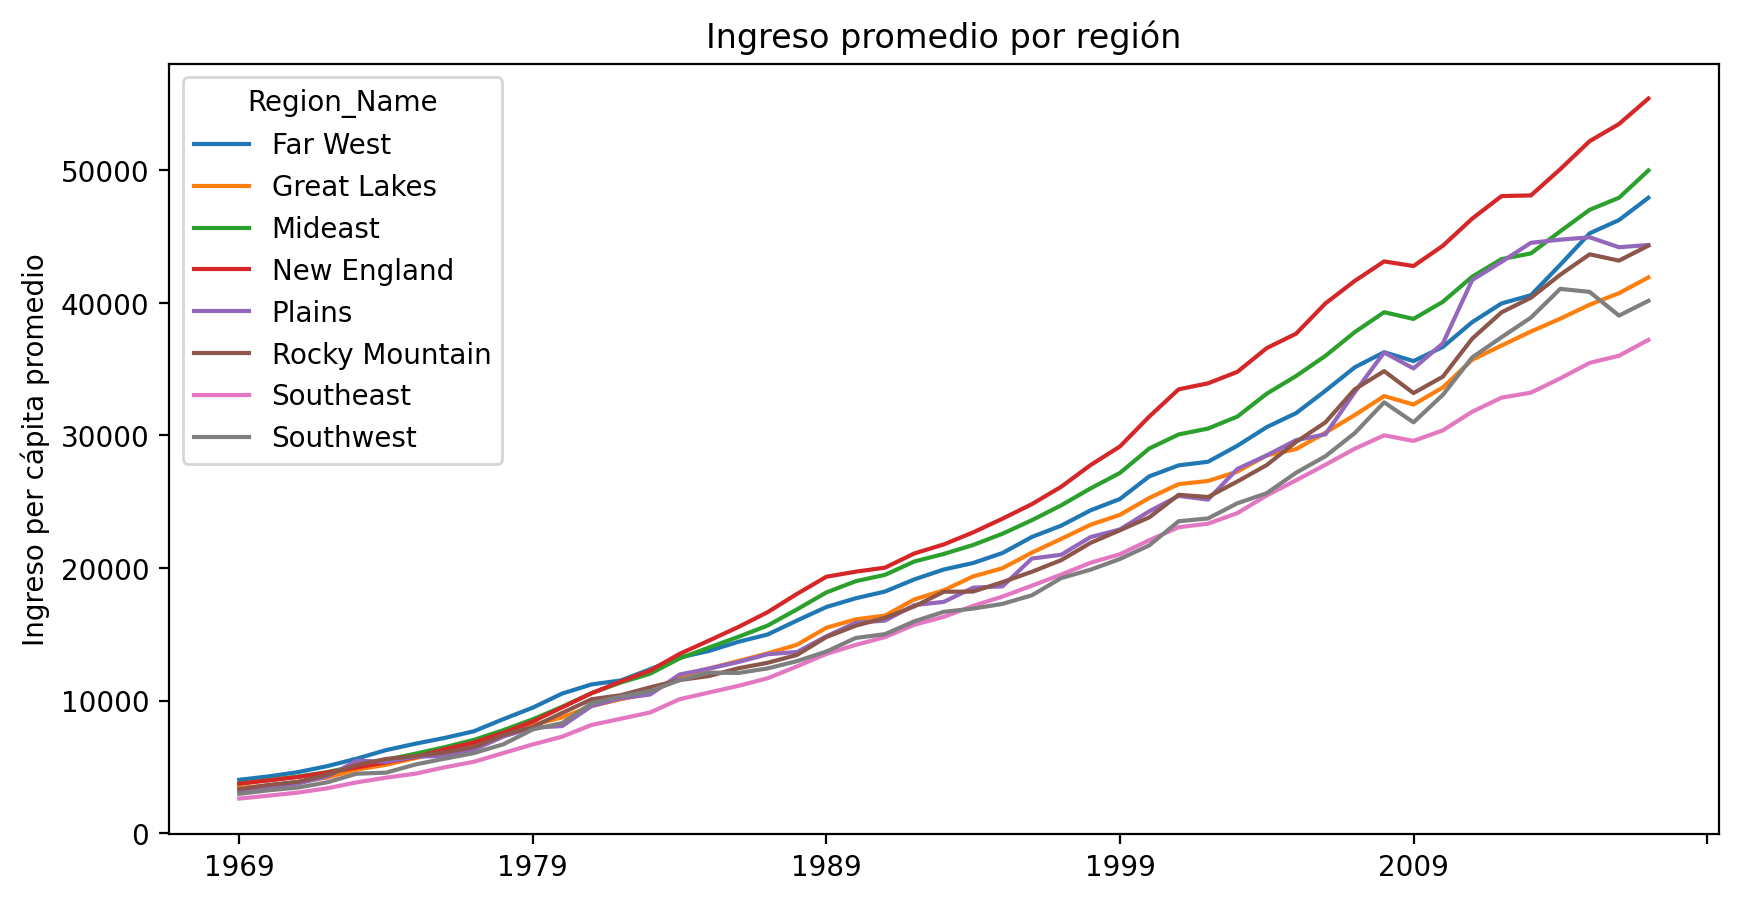

In [62]:
promedios_region = (
    pci_df.assign(Region_Name=pci_df.Region.map(nombres_regiones))
    .groupby("Region_Name")[anios]
    .mean()
)

promedios_region.T.plot.line(figsize=(10, 5), title="Ingreso promedio por región")
plt.ylabel("Ingreso per cápita promedio");

Ahora calculamos la descomposición de Theil con `TheilD`:

In [63]:
theil_dr = inequality.theil.TheilD(pci_df[anios].values, pci_df.Region)

El objeto resultante tiene dos atributos clave:
- `.bg` (between groups): componente entre regiones para cada año.
- `.wg` (within groups): componente dentro de regiones para cada año.

In [64]:
desigualdades["Theil_entre"] = theil_dr.bg
desigualdades["Theil_dentro"] = theil_dr.wg
desigualdades["Theil_entre_proporcion"] = (
    desigualdades["Theil_entre"] / desigualdades["Theil"]
)

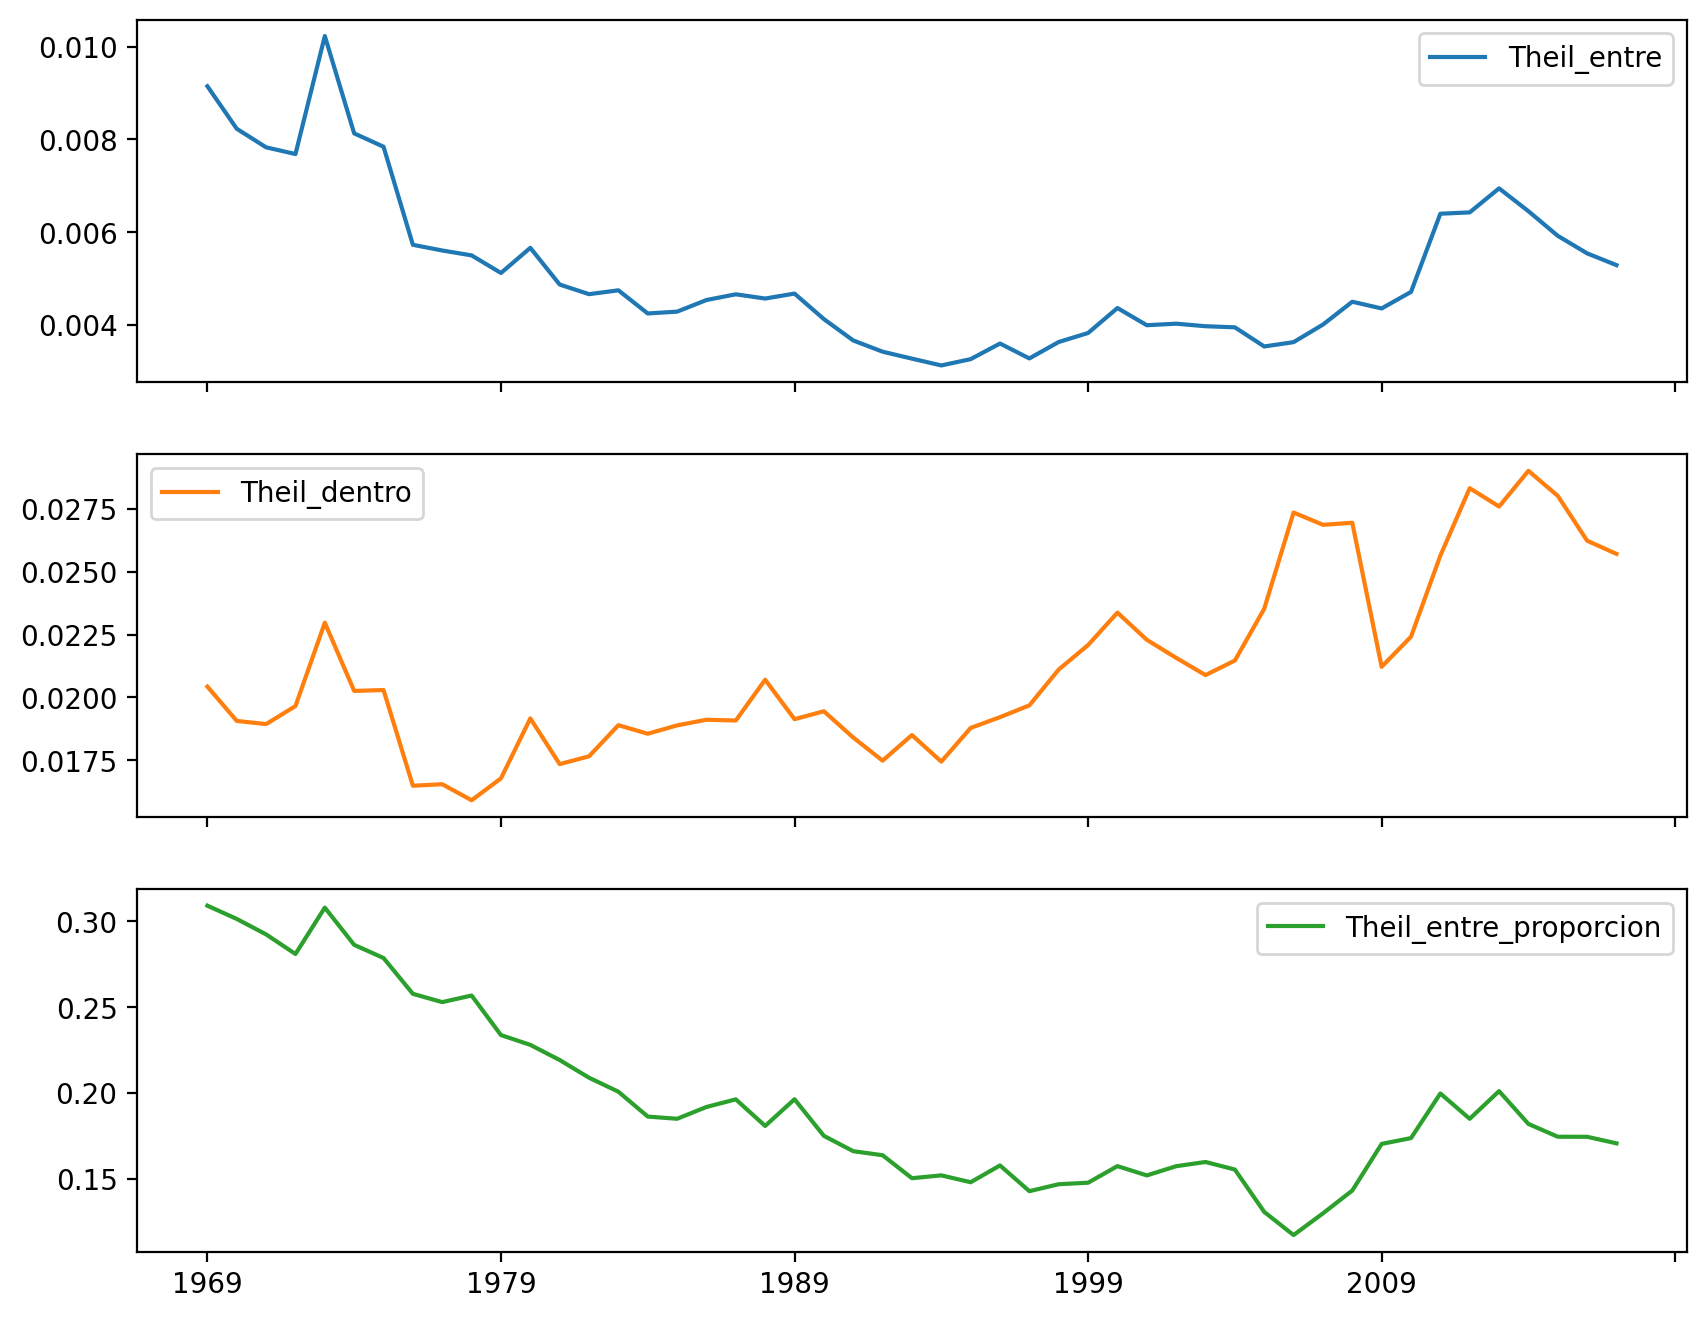

In [65]:
desigualdades[
    ["Theil_entre", "Theil_dentro", "Theil_entre_proporcion"]
].plot(subplots=True, figsize=(10, 8))
plt.show()

**Cómo leer este gráfico:**

- El componente *entre* regiones cae fuertemente entre 1969 y los 90 y luego se mantiene relativamente estable. Esto refleja la convergencia de regiones tradicionalmente pobres (como el Sur) hacia el promedio nacional.
- El componente *dentro* de las regiones sube en los últimos años: la desigualdad reciente viene cada vez más de diferencias entre condados de la *misma* región.
- La proporción que aporta lo *entre* regiones (panel inferior) toca su mínimo en los 2000, no en los 90 como el Gini total. Conclusión: la desigualdad regional clásica importa cada vez menos para explicar el total.

Esta es información que **los índices globales no podían darnos**.

### 5.3 Gini espacial: vecinos vs. no vecinos

La descomposición regional asume que las regiones están dadas (Sur, Noreste, etc.). Pero ¿qué pasa si queremos algo más fino, basado en vecindad real?

El **Gini espacial** descompone el Gini estándar en dos partes:

- Diferencias entre **pares de vecinos**.
- Diferencias entre **pares de no vecinos**.

La intuición: si hay fuerte autocorrelación espacial positiva (vecinos parecidos), la mayor parte del Gini debería venir de las diferencias entre lugares lejanos. Si la geografía no importa, ambos componentes deberían ser similares (proporcionalmente al número de pares).

El test de inferencia compara el componente observado contra lo que se obtendría si los ingresos se distribuyeran al azar en el mapa.

### Fórmula

La descomposición espacial del Gini parte la suma de diferencias en dos canastas según vecindad:

$$G = \underbrace{\frac{\sum_i\sum_j w_{ij}\,|y_i-y_j|}{2\,n^{2}\,\bar y}}_{\text{vecinos}}\;+\;\underbrace{\frac{\sum_i\sum_j (1-w_{ij})\,|y_i-y_j|}{2\,n^{2}\,\bar y}}_{\text{no vecinos}}$$

Es **literalmente la misma fórmula del Gini** (sección 3.2), pero con los pares separados según si son vecinos ($w_{ij}=1$) o no ($w_{ij}=0$).


In [66]:
from inequality.gini import Gini_Spatial

# El Gini espacial requiere matriz binaria (0/1, no estandarizada por filas)
wq.transform = "B"

In [67]:
gs69 = Gini_Spatial(pci_df["1969"], wq)
gs69



### Atributos del objeto `Gini_Spatial`

Cuando hacemos `gs69 = Gini_Spatial(pci_df["1969"], wq)` el objeto resultante guarda varios atributos. Los principales:

| Atributo       | Qué guarda                                  | Significado                                                                 |
|:---------------|:--------------------------------------------|:----------------------------------------------------------------------------|
| `gs69.g`       | Gini total                                  | El coeficiente de Gini estándar — mismo número que daría `Gini(...).g`.      |
| `gs69.wg`      | Componente entre **vecinos**                | Suma de diferencias $\|y_i - y_j\|$ cuando $i$ y $j$ son vecinos ($w_{ij}=1$). |
| `gs69.wcg`     | Componente entre **no vecinos**             | Suma de diferencias $\|y_i - y_j\|$ cuando $i$ y $j$ **no** son vecinos.       |
| `gs69.wcg_share` | Proporción aportada por los no-vecinos    | $\dfrac{\text{wcg}}{\text{Gini total}}$ — fracción del Gini que viene de pares lejanos. Cerca de 1 significa que casi todo el Gini son diferencias entre lugares lejanos (autocorrelación positiva). |
| `gs69.p_sim`   | P-valor por permutaciones                   | Probabilidad de obtener un componente espacial igual o más extremo bajo la hipótesis nula de que los ingresos están distribuidos al azar en el mapa. P bajo (< 0.05) → patrón significativo. |


In [68]:
print(f"Gini total 1969: {gs69.g:.4f}")
print(f"Componente entre no-vecinos: {gs69.wcg_share:.4f}")
print(f"P-valor: {gs69.p_sim}")

Gini total 1969: 0.1356
Componente entre no-vecinos: 0.1354
P-valor: 0.01


Casi todo el Gini (0.1354 de 0.1356) viene de diferencias entre **no vecinos**. La fracción aportada por los vecinos es minúscula. Esto refleja autocorrelación positiva fuerte: los vecinos se parecen, así que las diferencias grandes ocurren entre lugares distantes.

**Cuidado al interpretar:** el componente "entre vecinos" es pequeño en parte porque hay pocos pares de vecinos comparados con todos los pares posibles:

In [69]:
print(f"Pares de vecinos: {wq.pct_nonzero:.2f}% del total de pares posibles")

Pares de vecinos: 0.19% del total de pares posibles


Solo el 0.19% de los pares posibles son vecinos. La inferencia (p-valor) es lo importante: nos dice si lo observado es distinto de lo que pasaría con ingresos aleatoriamente distribuidos en el mapa.



In [70]:
def gini_espacial_de_columna(ingresos, pesos):
    """Calcula el Gini espacial de un año y devuelve sus componentes."""
    
    # 1. Calcular el Gini espacial (objeto con todos los componentes)
    gs = Gini_Spatial(ingresos, pesos)
    
    # 2. Denominador 2*n²*ȳ — sirve para normalizar las sumas crudas
    #    y dejarlas en escala de Gini (entre 0 y 1)
    denom = 2 * ingresos.mean() * pesos.n ** 2
    
    # 3. Devolver una fila con los 4 valores de interés
    return pandas.Series({
        "gini": gs.g,                              # Gini total
        "Diferencias_cercanas": gs.wg / denom,     # Aporte de pares vecinos
        "Diferencias_lejanas": gs.wcg / denom,     # Aporte de pares no-vecinos
        "p_valor": gs.p_sim,                       # P-valor del test de permutaciones
    })

In [71]:

gini_espacial = pci_df[anios].apply(gini_espacial_de_columna, pesos=wq).T
gini_espacial.head()

,gini,Diferencias_cercanas,Diferencias_lejanas,p_valor
1969,0.135562,0.000144,0.135418,0.01
1970,0.130076,0.000141,0.129935,0.01
1971,0.128540,0.000142,0.128398,0.01
1972,0.129126,0.000140,0.128985,0.01
1973,0.142166,0.000145,0.142021,0.01


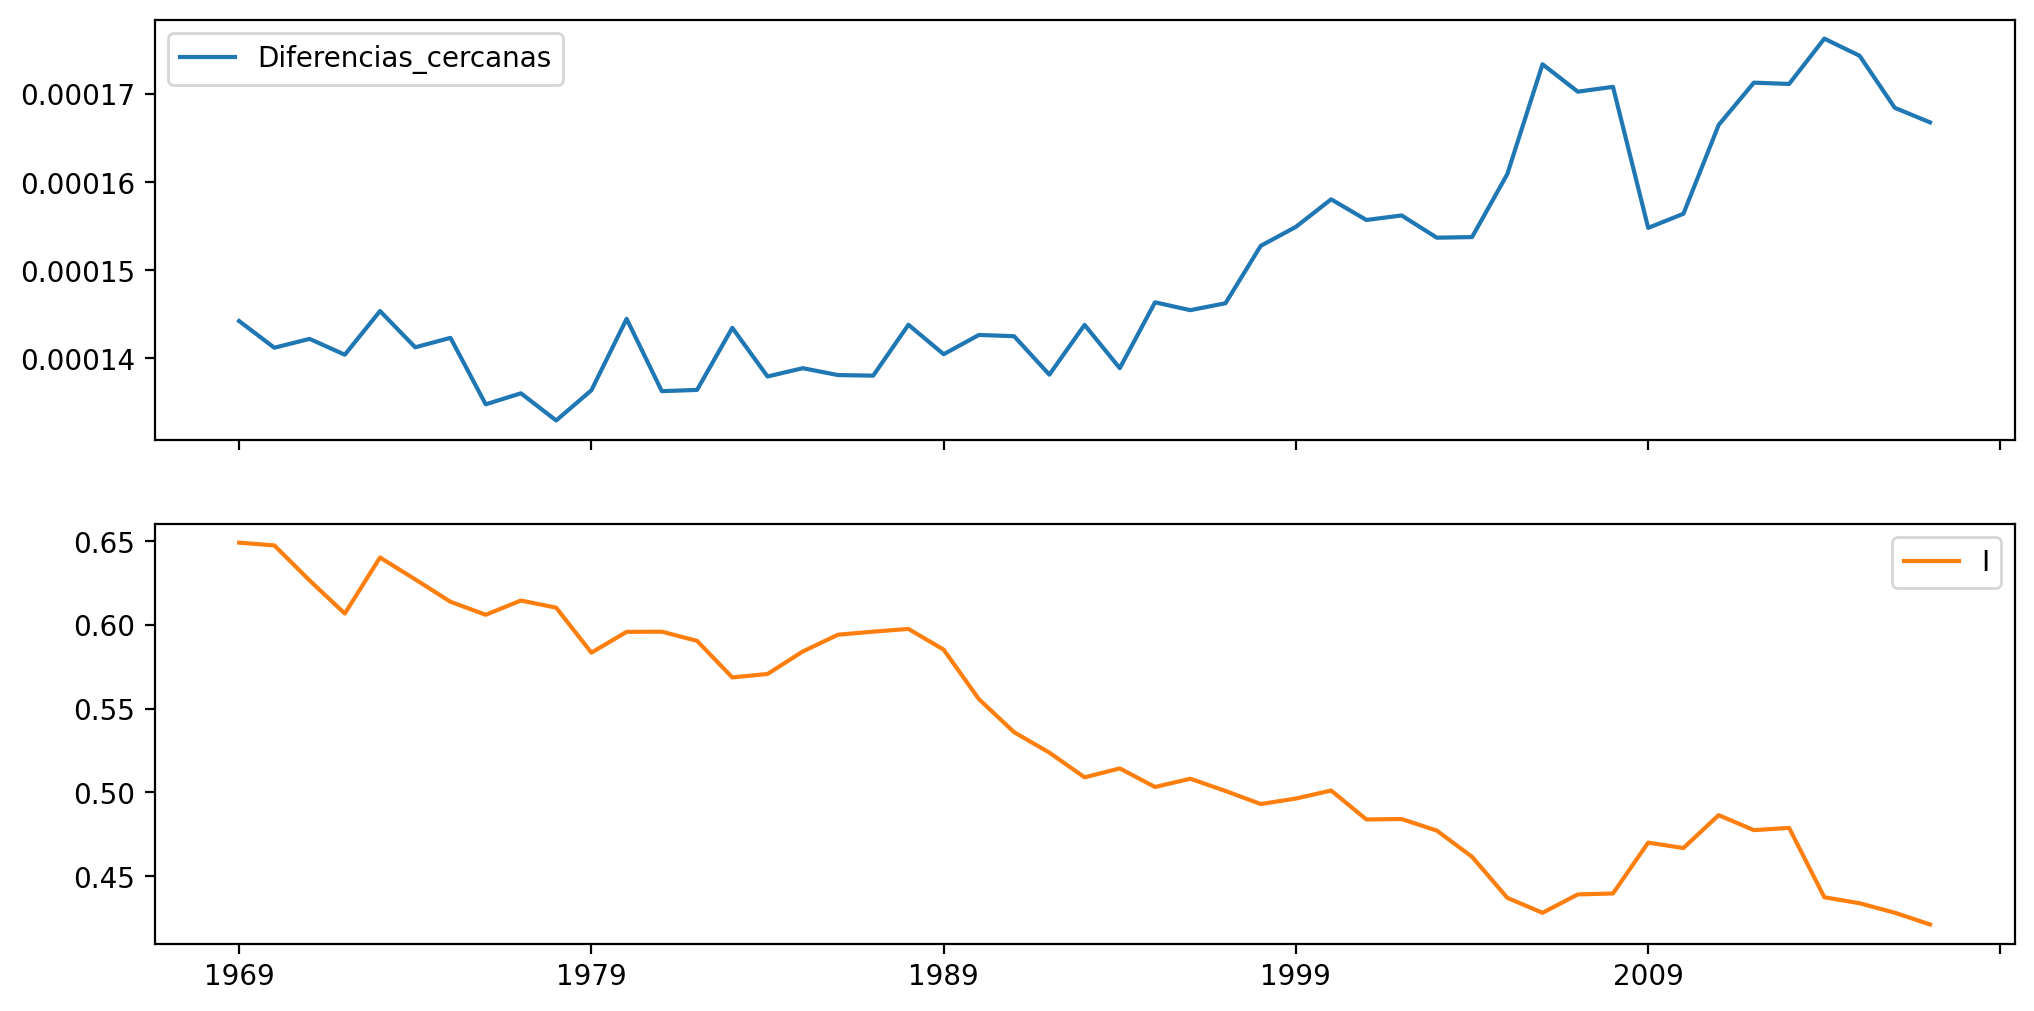

In [72]:
desigualdades["Diferencias_cercanas"] = gini_espacial["Diferencias_cercanas"]

desigualdades[["Diferencias_cercanas", "I"]].plot.line(
    subplots=True, figsize=(12, 6)
)
plt.show()

**Relación entre los dos paneles:** las diferencias entre vecinos suben con el tiempo, mientras Moran's I baja. Esto es coherente: a medida que la autocorrelación espacial se debilita, los vecinos se parecen menos, así que las diferencias entre ellos crecen. Son dos formas distintas de capturar la misma historia.

## 6. Conclusión

Las medidas clásicas de desigualdad (Gini, Theil, ratio 20:20) tratan a las observaciones como si fueran intercambiables. Para datos espaciales esto pierde información valiosa: dos sociedades pueden tener el mismo Gini pero geografías de la desigualdad muy distintas.

Vimos tres formas complementarias de incorporar el espacio:

1. **Moran's I del ingreso:** mide qué tan agrupados están geográficamente los ricos y los pobres.
2. **Descomposición regional del Theil:** separa cuánta desigualdad viene de diferencias entre regiones predefinidas vs. dentro de ellas.
3. **Gini espacial:** separa diferencias entre vecinos vs. no vecinos, sin necesidad de definir regiones.

**Hallazgo clave del caso de EE.UU.:** entre 1969 y 2017, la desigualdad agregada tuvo forma de U, pero la *estructura geográfica* de la desigualdad cayó de forma sostenida. El sur dejó de ser sistemáticamente más pobre. Hoy la desigualdad ocurre más bien dentro de cada región que entre regiones. Sin las herramientas espaciales, esta historia no aparece.


## Para profundizar

- Rey, S. & Le Gallo, J. (2009). Spatial analysis of economic convergence. *Palgrave Handbook of Econometrics*.
- Rodríguez-Pose, A. (2018). The revenge of the places that don't matter. *Cambridge Journal of Regions, Economy and Society*, 11(1).